In [1]:
from masa.common.utils import make_env
import sys
sys.path.append('/vol/bitbucket/ma5923/_projects/provably-safe-policy-updates/rl_project')
from utils.shield_utils import synthesise_shield
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

%load_ext autoreload
%autoreload 2

from masa.envs.tabular import colour_grid_world as cgw
from masa.envs.tabular import colour_bomb_grid_world as cbgw
from masa.envs.tabular import colour_bomb_grid_world_v2 as cbgw2
from masa.envs.tabular import colour_bomb_grid_world_v3 as cbgw3

## Colour Grid World

In [4]:
env = cgw.ColourGridWorld(render_mode='rgb_array', slip_prob=0.0)

output = synthesise_shield(
    env=env, 
    transition_matrix_fn=cgw.get_transition_matrix, 
    label_fn=cgw.label_fn, 
    cost_fn=cgw.cost_fn
)

Calculating the maximum number of successor states ...
Calculated maximum number of successor states [5] ...
Building successor state matrix and probabilities ...
Computing almost sure safe set ...


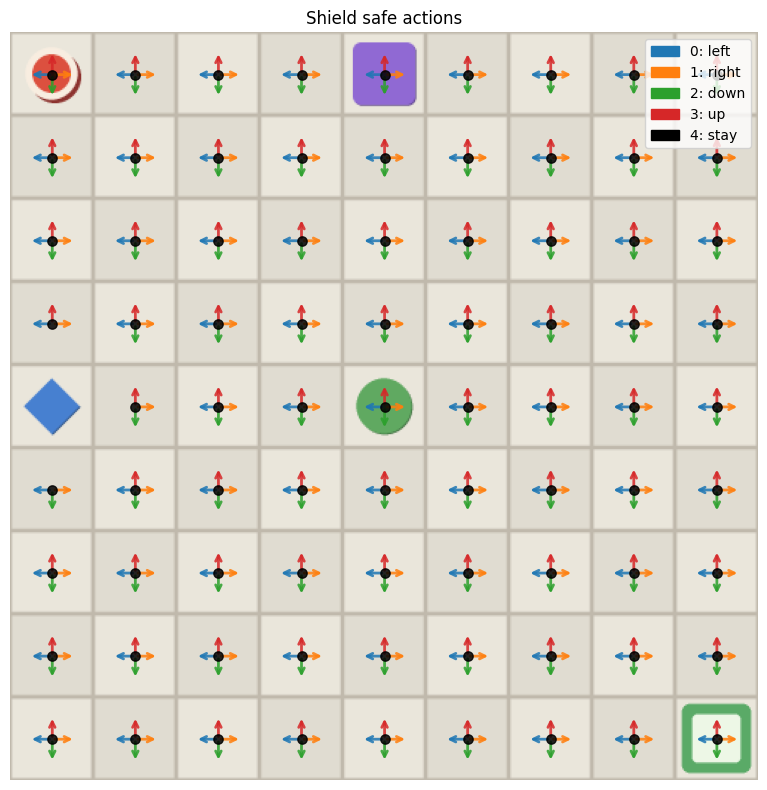

In [5]:
# output shape: (n_states, n_actions), 1 means action is safe
safe_actions_by_state = np.asarray(output)

ACTION_VECTORS = {
    0: (-1, 0),  # left
    1: (1, 0),   # right
    2: (0, 1),   # down
    3: (0, -1),  # up
    4: (0, 0),   # stay
}

ACTION_COLORS = {
    0: "tab:blue",
    1: "tab:orange",
    2: "tab:green",
    3: "tab:red",
    4: "black",
}

ACTION_LABELS = {
    0: "left",
    1: "right",
    2: "down",
    3: "up",
    4: "stay",
}


def plot_colour_bomb_safe_actions(env, safe_actions_by_state, *, title="Shield safe actions"):
    env.reset(seed=0)
    frame = env.render()

    grid_size = env.unwrapped._grid_size
    nrow = env.unwrapped._nrow
    ncol = env.unwrapped._ncol

    img_h, img_w = frame.shape[:2]
    cell_w = img_w / ncol
    cell_h = img_h / nrow

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(frame)
    ax.axis("off")
    ax.set_title(title)

    for state in range(safe_actions_by_state.shape[0]):
        row = state // grid_size
        col = state % grid_size

        cx = (col + 0.5) * cell_w
        cy = (row + 0.5) * cell_h

        safe_actions = np.flatnonzero(safe_actions_by_state[state] > 0)

        for action in safe_actions:
            dx_unit, dy_unit = ACTION_VECTORS[int(action)]
            color = ACTION_COLORS[int(action)]

            if action == 4:
                # Stay action: draw a small filled circle.
                ax.scatter(cx, cy, s=45, color=color, alpha=0.85, zorder=5)
                continue

            dx = dx_unit * cell_w * 0.28
            dy = dy_unit * cell_h * 0.28

            ax.annotate(
                "",
                xy=(cx + dx, cy + dy),
                xytext=(cx, cy),
                arrowprops=dict(
                    arrowstyle="->",
                    color=color,
                    lw=2.0,
                    alpha=0.85,
                ),
                zorder=5,
            )

    legend_handles = [
        mpatches.Patch(color=ACTION_COLORS[a], label=f"{a}: {ACTION_LABELS[a]}")
        for a in ACTION_VECTORS
    ]
    ax.legend(handles=legend_handles, loc="upper right", frameon=True)

    plt.tight_layout()
    return fig, ax


fig, ax = plot_colour_bomb_safe_actions(env, output)
plt.show()

In [6]:
import numpy as np

from masa.envs.tabular import colour_bomb_grid_world_v2 as cbgw2
from masa.prob_shield.helpers import build_successor_states_matrix
from masa.prob_shield.interval_bound_vi import interval_bound_value_iteration

env = cbgw2.ColourBombGridWorldV2(render_mode="rgb_array")

successor_states_matrix, probabilities, max_successors, label_fn, cost_fn, safe_set = (
    build_successor_states_matrix(
        env,
        label_fn=cbgw2.label_fn,
        cost_fn=cbgw2.cost_fn,
    )
)

v_inf, v_sup, delta, steps = interval_bound_value_iteration(
    successor_states_matrix,
    probabilities,
    label_fn,
    cost_fn,
    safe_set,
    theta=1e-10,
    max_steps=1000,
)

print("successor_states_matrix:", successor_states_matrix.shape)
print("probabilities:", probabilities.shape)
print("max_successors:", max_successors)
print("safe_set size:", len(safe_set))
print("VI steps:", steps)
print("final delta:", delta)

for s in env.unwrapped._start_states:
    print(f"start state {s}: risk upper bound = {v_sup[s]:.6f}")

Calculating the maximum number of successor states ...
Calculated maximum number of successor states [5] ...
Building successor state matrix and probabilities ...
Computing almost sure safe set ...
Initializing value iteration ...


Completed value iteration ...
successor_states_matrix: (5, 225)
probabilities: (5, 225, 5)
max_successors: 5
safe_set size: 8
VI steps: 1000
final delta: 0.0008466551526272141
start state 16: risk upper bound = 0.000848
start state 199: risk upper bound = 0.000001
start state 178: risk upper bound = 0.000824
start state 112: risk upper bound = 0.001519
start state 26: risk upper bound = 0.000825


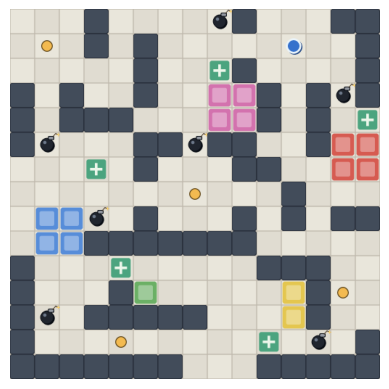

In [14]:
env = cbgw2.ColourBombGridWorldV2(render_mode="rgb_array")
obs, info = env.reset()
frame = env.render()
plt.imshow(frame)
plt.axis('off')
plt.show();

In [12]:
safe_set

[14, 38, 74, 93, 154, 205, 210, 224]

In [16]:
def almost_sure_safe_actions(state):
    actions = []
    succs = successor_states_matrix[:, state]

    for action in range(env.action_space.n):
        probs = probabilities[:, state, action]
        support = succs[(probs > 0.0) & (succs != -1)]

        if len(support) > 0 and all(int(sp) in safe_set for sp in support):
            actions.append(action)

    return actions


# for s in env.unwrapped._start_states:
for s in safe_set:
    print(s, almost_sure_safe_actions(s))

14 [0, 1, 2, 3, 4]
38 [1, 4]
74 [1, 3, 4]
93 [4]
154 [2, 3, 4]
205 [2, 4]
210 [0, 1, 2, 3, 4]
224 [0, 1, 2, 3, 4]


In [37]:
def compute_q_value_intervals(state, v_inf, v_sup, label_fn = None, cost_fn = None):
    """
    Compute Q-function safety critic intervals: 
    probability interval that you reach an unsafe state 
    if you choose action a and the choose the safest action in each state.
    """

    # if cost_fn(label_fn(state)):
    #     return [
    #         (action, (1.0, 1.0))
    #         for action in range(env.action_space.n)
    #     ]

    succs = successor_states_matrix[:, state]

    q_value_intervals_lst = []
    for action in range(env.action_space.n):
        q_value_sup = 0.0
        q_value_inf = 0.0
        for k, sp in enumerate(succs):
            if sp == -1:
                continue
            q_value_inf += probabilities[k, state, action] * v_inf[int(sp)]
            q_value_sup += probabilities[k, state, action] * v_sup[int(sp)]

        q_value_intervals_lst.append((action, (float(q_value_inf), float(q_value_sup))))

    return q_value_intervals_lst

def safest_actions_by_q_sup(state, v_inf, v_sup):
    q_intervals = compute_q_value_intervals(state, v_inf, v_sup)
    min_q_sup = min(q_sup for _, (_, q_sup) in q_intervals)
    return [
        (action, interval)
        for action, interval in q_intervals
        if interval[1] == min_q_sup
    ]

In [53]:
safest_actions_lst = []
safest_actions_upper_unsafety_prob_lst = []
for s in range(env.observation_space.n):
    print(f'State: {s}')
    q_value_intervals = compute_q_value_intervals(s, v_inf, v_sup)
    print(q_value_intervals)
    safest_actions_output = safest_actions_by_q_sup(state=s, v_inf=v_inf, v_sup=v_sup)
    safest_actions = [tup[0] for tup in safest_actions_output]
    safest_actions_upper_unsafety_prob = [tup[1][1] for tup in safest_actions_output]
    print('Safest actions:', safest_actions)
    print('Upper bounds for unsafety probs:', safest_actions_upper_unsafety_prob)
    safest_actions_upper_unsafety_prob_lst.append(safest_actions_upper_unsafety_prob)
    safest_actions_lst.append(safest_actions)

State: 0
[(0, (6.232146593300183e-07, 0.0008472776530081627)), (1, (6.225699258100721e-07, 0.0008472769796271979)), (2, (6.474500649133434e-07, 0.0008473018947228958)), (3, (6.232146593300183e-07, 0.0008472776530081627)), (4, (6.232146593300183e-07, 0.0008472776530081627))]
Safest actions: [1]
Upper bounds for unsafety probs: [0.0008472769796271979]
State: 1
[(0, (6.344727490602983e-07, 0.000847288896711457)), (1, (6.218330875015714e-07, 0.0008472762100489525)), (2, (1.0660256902820974e-06, 0.0008477200280849588)), (3, (6.33828015540352e-07, 0.0008472882233304923)), (4, (6.33828015540352e-07, 0.0008472882233304923))]
Safest actions: [1]
Upper bounds for unsafety probs: [0.0008472762100489525]
State: 2
[(0, (6.204242466079959e-07, 0.0008472748275681404)), (1, (6.084293185692153e-07, 0.0008472628142866006)), (2, (6.08124598314783e-07, 0.0008472624805843354)), (3, (6.084293185692153e-07, 0.0008472628142866006)), (4, (6.084293185692153e-07, 0.0008472628142866006))]
Safest actions: [2]
Uppe

In [55]:
safest_actions_upper_unsafety_prob_lst

[[0.0008472769796271979],
 [0.0008472762100489525],
 [0.0008472624805843354],
 [0.0008466992464501152],
 [0.0008466836010574979],
 [0.0008466836007389295],
 [0.0008466836007300804],
 [0.02715504903100391],
 [0.0988233095380733],
 [0.02713785493134442],
 [0.0008256749280564378],
 [0.0008252237746032081],
 [0.0008262462390515934],
 [0.0008469260539354725],
 [0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0008473046844440356],
 [0.0008477697011969142],
 [0.0008472620992103184],
 [0.0008466992375663182],
 [0.0008466836125259596],
 [0.00015435819498066058],
 [0.00011589567211111703],
 [0.0014112535518655655],
 [0.025716037013664664],
 [0.0015141899810562746],
 [0.0008419164523727081],
 [0.0008251828407726076],
 [0.0008630549591934634],
 [0.0015913993897551171],
 [0.0015913993897551171],
 [0.0008478370410973105],
 [0.000867001880615206],
 [0.0008472479885614124],
 [0.0008466988773752262],
 [0.0008466840253905824],
 [8.0886011162632e-05],
 [5.9613844100744475e-05],
 [5.6997411277148924e-05],
 [0.0, 0.0],
 [8.

In [60]:
env.unwrapped._start_states

[16, 199, 178, 112, 26]

In [61]:
for s in env.unwrapped._start_states:
    print(safest_actions_upper_unsafety_prob_lst[s])

[0.0008477697011969142]
[1.1882648357324029e-06]
[0.0008235643367216564]
[0.0015187246912850814]
[0.0008251828407726076]


In [46]:
import torch
from torch.utils.data import TensorDataset

n_states = env.observation_space.n
n_actions = env.action_space.n

states = torch.arange(n_states, dtype=torch.long)

safest_action_multihot = torch.zeros((n_states, n_actions), dtype=torch.float32)

for state, safest_actions in enumerate(safest_actions_lst):
    safest_action_multihot[state, safest_actions] = 1.0

safest_actions_dataset = TensorDataset(states, safest_action_multihot)

print("States shape:", safest_actions_dataset.tensors[0].shape)
print("Actions shape:", safest_actions_dataset.tensors[1].shape)

States shape: torch.Size([225])
Actions shape: torch.Size([225, 5])


In [47]:
safest_action_multihot

tensor([[0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        ...,
        [1., 1., 1., 1., 1.],
        [0., 0., 0., 1., 0.],
        [1., 1., 1., 1., 1.]])

In [77]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


def plot_safest_actions_dataset(
    env,
    safest_actions_dataset,
    *,
    v_sup,
    successor_states_matrix,
    probabilities,
    title="Safest actions colored by unsafe-reachability probability",
    seed=0,
    skip_walls=True,
    skip_empty_action_masks=True,
    arrow_scale=0.45,
    arrow_width=2.0,
    stay_marker_size=48,
    cmap="RdYlGn_r",
    vmin=0.0,
    vmax=1.0,
    save_path=None,
):
    action_vectors = {
        0: (-1, 0),  # left
        1: (1, 0),   # right
        2: (0, 1),   # down
        3: (0, -1),  # up
        4: (0, 0),   # stay
    }

    unwrapped = env.unwrapped
    grid_size = int(unwrapped._grid_size)
    nrow = int(getattr(unwrapped, "_nrow", grid_size))
    ncol = int(getattr(unwrapped, "_ncol", grid_size))
    grid_area = grid_size * grid_size

    wall_states = set(getattr(unwrapped, "_wall_states", []))
    wall_base_states = {int(s) % grid_area for s in wall_states}

    states_tensor, action_masks_tensor = safest_actions_dataset.tensors

    if states_tensor.ndim == 1:
        state_indices = states_tensor.detach().cpu().long().numpy()
    else:
        state_indices = states_tensor.detach().cpu().argmax(dim=1).long().numpy()

    action_masks = action_masks_tensor.detach().cpu().numpy()

    env.reset(seed=seed)
    frame = env.render()
    if frame is None:
        raise RuntimeError("env.render() returned None. Create env with render_mode='rgb_array'.")

    img_h, img_w = frame.shape[:2]
    cell_w = img_w / ncol
    cell_h = img_h / nrow

    risk_boundaries = [0.0, 0.05, 0.1, 1.0]
    risk_colors = ["darkgreen", "tab:orange", "tab:red"]
    cmap = mpl.colors.ListedColormap(risk_colors)
    norm = mpl.colors.BoundaryNorm(
        risk_boundaries,
        cmap.N,
        clip=True,
    )
    scalar_map = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    # norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    # scalar_map = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    def q_sup(state, action):
        value = 0.0
        succs = successor_states_matrix[:, state]
        for k, sp in enumerate(succs):
            if sp == -1:
                continue
            value += probabilities[k, state, action] * v_sup[int(sp)]
        return float(value)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(frame)
    ax.axis("off")
    ax.set_title(title)

    for state_idx, action_mask in zip(state_indices, action_masks):
        state_idx = int(state_idx)
        base_state = state_idx % grid_area

        if skip_walls and base_state in wall_base_states:
            continue

        safest_actions = np.flatnonzero(action_mask > 0)
        if skip_empty_action_masks and len(safest_actions) == 0:
            continue

        row = base_state // ncol
        col = base_state % ncol
        cx = (col + 0.5) * cell_w
        cy = (row + 0.5) * cell_h

        for action in safest_actions:
            action = int(action)
            risk_upper = q_sup(state_idx, action)
            color = scalar_map.to_rgba(risk_upper)

            dx_unit, dy_unit = action_vectors[action]

            if action == 4:
                ax.scatter(
                    cx,
                    cy,
                    s=stay_marker_size,
                    color=color,
                    edgecolor="black",
                    linewidth=0.4,
                    alpha=0.9,
                    zorder=6,
                )
                continue

            dx = dx_unit * cell_w * arrow_scale
            dy = dy_unit * cell_h * arrow_scale

            ax.annotate(
                "",
                xy=(cx + dx, cy + dy),
                xytext=(cx, cy),
                arrowprops=dict(
                    arrowstyle="->",
                    
                    color=color,
                    lw=arrow_width,
                    alpha=0.9,
                ),
                zorder=6,
            )

    cbar = fig.colorbar(scalar_map, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Upper bound on unsafe-reachability probability")

    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight", dpi=150)

    return fig, ax

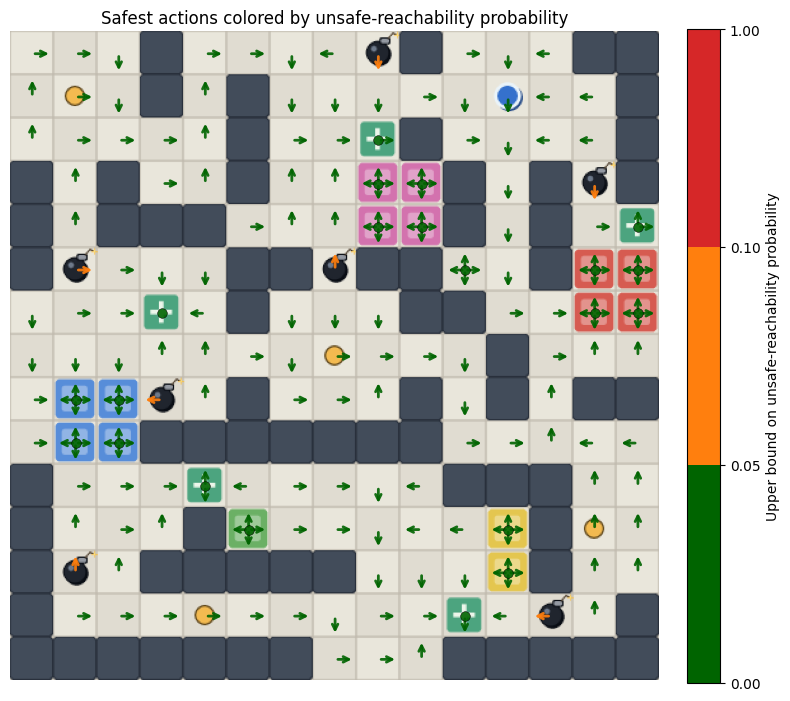

In [78]:
fig, ax = plot_safest_actions_dataset(
    env,
    safest_actions_dataset,
    v_sup=v_sup,
    successor_states_matrix=successor_states_matrix,
    probabilities=probabilities,
    arrow_scale=0.45
)
plt.show()

### Safety finetuning

In [79]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


def train_policy_on_safest_actions(
    safest_actions_dataset,
    *,
    n_states,
    n_actions,
    hidden_dim=128,
    lr=1e-3,
    batch_size=256,
    max_epochs=5000,
    target_accuracy=1.0,
    device="cpu",
):
    states, action_masks = safest_actions_dataset.tensors

    # Convert integer states to one-hot if needed.
    if states.ndim == 1:
        x = F.one_hot(states.long(), num_classes=n_states).float()
    else:
        x = states.float()

    y = action_masks.float()

    dataset = TensorDataset(x, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = nn.Sequential(
        nn.Linear(n_states, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, n_actions),
    ).to(device)

    x = x.to(device)
    y = y.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    def safest_action_accuracy():
        model.eval()
        with torch.no_grad():
            logits = model(x)
            preds = logits.argmax(dim=1)
            correct = y[torch.arange(y.shape[0], device=device), preds] > 0
            return correct.float().mean().item()

    for epoch in range(1, max_epochs + 1):
        model.train()

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)

            # Multi-label objective: maximize probability mass on safest actions.
            log_probs = F.log_softmax(logits, dim=1)
            safe_counts = yb.sum(dim=1).clamp_min(1.0)
            loss = -(log_probs * yb).sum(dim=1) / safe_counts
            loss = loss.mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        acc = safest_action_accuracy()

        if epoch % 100 == 0 or acc >= target_accuracy:
            print(f"epoch={epoch:04d} loss={loss.item():.6f} acc={acc:.4f}")

        if acc >= target_accuracy:
            print(f"Reached {target_accuracy:.2%} accuracy at epoch {epoch}")
            break

    return model


policy_net = train_policy_on_safest_actions(
    safest_actions_dataset,
    n_states=env.observation_space.n,
    n_actions=env.action_space.n,
    hidden_dim=128,
    lr=1e-3,
    device="cpu",
)

epoch=0100 loss=0.265405 acc=0.9956
epoch=0136 loss=0.233878 acc=1.0000
Reached 100.00% accuracy at epoch 136


In [80]:
def evaluate_safest_action_accuracy(model, safest_actions_dataset, n_states, device="cpu"):
    states, action_masks = safest_actions_dataset.tensors

    if states.ndim == 1:
        x = F.one_hot(states.long(), num_classes=n_states).float()
    else:
        x = states.float()

    x = x.to(device)
    y = action_masks.float().to(device)

    model.eval()
    with torch.no_grad():
        logits = model(x)
        preds = logits.argmax(dim=1)
        correct = y[torch.arange(y.shape[0], device=device), preds] > 0

    return correct.float().mean().item()


acc = evaluate_safest_action_accuracy(
    policy_net,
    safest_actions_dataset,
    n_states=env.observation_space.n,
)

print("Accuracy:", acc)

Accuracy: 1.0


In [81]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


def policy_action(policy_net, obs, env, device=None):
    if device is None:
        device = next(policy_net.parameters()).device

    n_states = env.observation_space.n

    # MASA tabular envs return integer observations.
    if np.isscalar(obs):
        x = F.one_hot(torch.tensor([int(obs)]), num_classes=n_states).float()
    else:
        x = torch.as_tensor(obs, dtype=torch.float32).unsqueeze(0)

    x = x.to(device)

    policy_net.eval()
    with torch.no_grad():
        logits = policy_net(x)
        action = int(logits.argmax(dim=1).item())

    return action


def record_policy_episodes(
    env,
    policy_net,
    *,
    n_episodes=5,
    max_steps=50,
    seed=0,
):
    all_episode_frames = []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)

        frames = []
        frame = env.render()
        frames.append(frame.copy())

        for _ in range(max_steps):
            action = policy_action(policy_net, obs, env)
            obs, reward, terminated, truncated, info = env.step(action)

            frame = env.render()
            frames.append(frame.copy())

            if terminated or truncated:
                break

        all_episode_frames.append(frames)

    return all_episode_frames


def _select_frame_indices(n_frames, max_columns=5):
    n_cols = min(max_columns, n_frames)

    if n_cols == 1:
        return [0]

    return np.linspace(0, n_frames - 1, n_cols).round().astype(int).tolist()


def plot_recorded_episodes(
    all_episode_frames,
    *,
    max_columns=5,
    figsize_per_cell=(2.4, 2.4),
):
    n_episodes = len(all_episode_frames)
    n_cols = min(max_columns, max(len(frames) for frames in all_episode_frames))

    fig, axes = plt.subplots(
        n_episodes,
        n_cols,
        figsize=(figsize_per_cell[0] * n_cols, figsize_per_cell[1] * n_episodes),
        squeeze=False,
    )

    for ep, frames in enumerate(all_episode_frames):
        frame_indices = _select_frame_indices(len(frames), max_columns=n_cols)

        for col in range(n_cols):
            ax = axes[ep, col]
            ax.axis("off")

            if col < len(frame_indices):
                idx = frame_indices[col]
                ax.imshow(frames[idx])

                if col == 0:
                    ax.set_title("First")
                elif col == n_cols - 1:
                    ax.set_title("Last")
                else:
                    ax.set_title(f"t={idx}")

    plt.tight_layout()
    return fig, axes

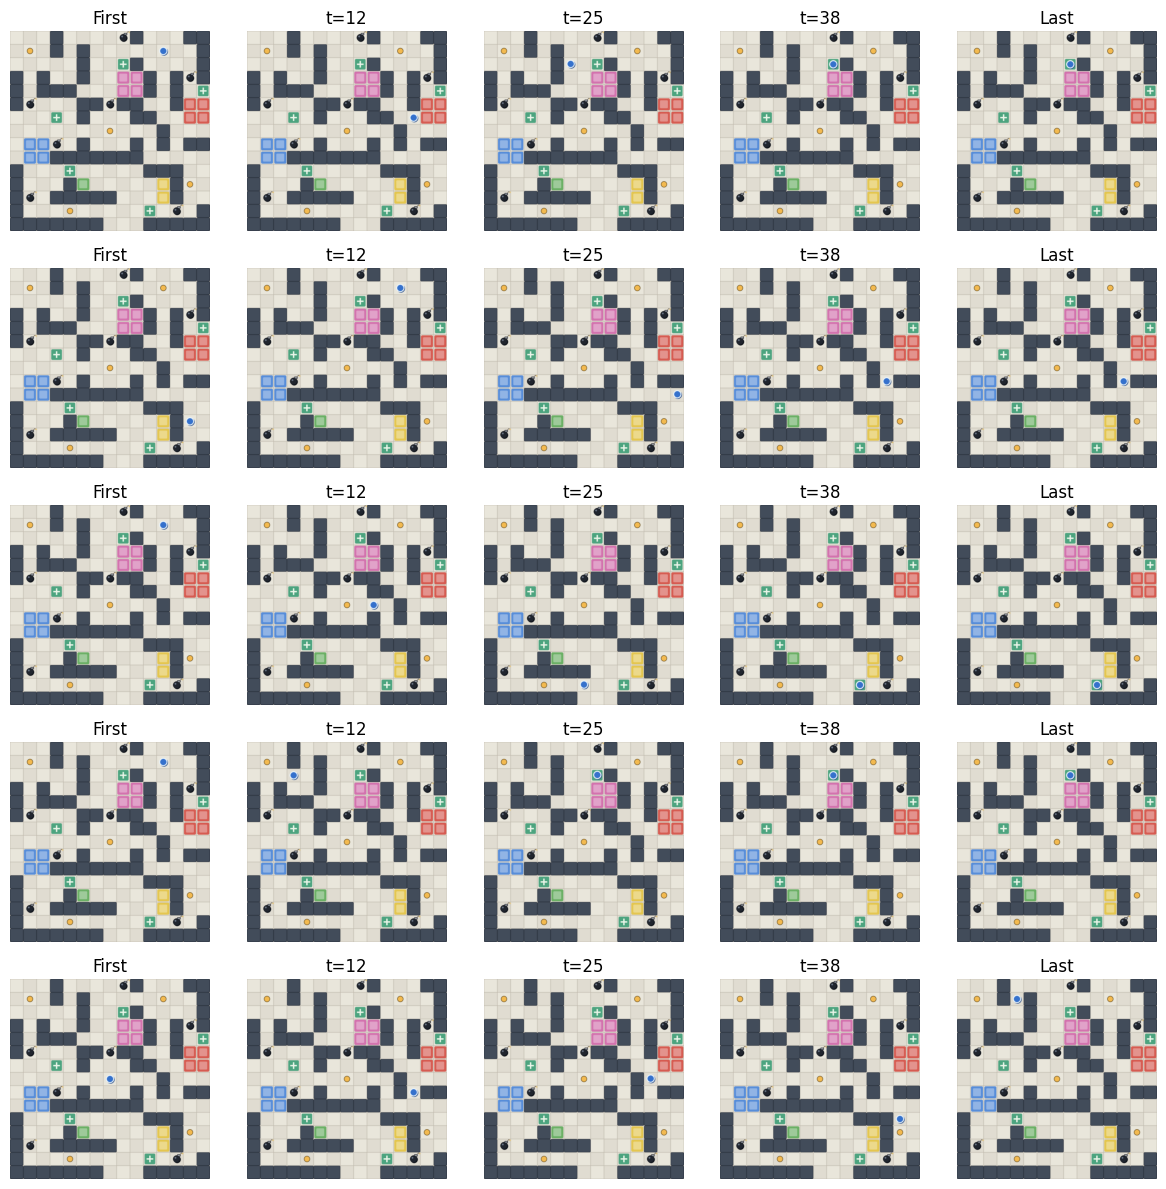

In [82]:
# Make sure env was created with render_mode="rgb_array"
# env = cbgw2.ColourBombGridWorldV2(render_mode="rgb_array")

episode_frames = record_policy_episodes(
    env,
    policy_net,
    n_episodes=5,
    max_steps=50,
    seed=0,
)

fig, axes = plot_recorded_episodes(
    episode_frames,
    max_columns=5,
)

plt.show()

In [87]:
import numpy as np

start_states = list(env.unwrapped._start_states)
p0 = np.ones(len(start_states)) / len(start_states)

initial_risk_lower = float(np.sum(p0 * v_inf[start_states]))
initial_risk_upper = float(np.sum(p0 * v_sup[start_states]))

worst_case_start_lower = float(np.max(v_inf[start_states]))
worst_case_start_upper = float(np.max(v_sup[start_states]))

print("Start states:", start_states)
print(f"Initial-distribution risk interval: [{100*initial_risk_lower:.4f}%, {100*initial_risk_upper:.4f}%]")
print(f"Worst-case start risk interval:      [{100*worst_case_start_lower:.4f}%, {100*worst_case_start_upper:.4f}%]")

Start states: [16, 199, 178, 112, 26]
Initial-distribution risk interval: [0.0152%, 0.0803%]
Worst-case start risk interval:      [0.0716%, 0.1519%]


### What we did:
1. Synthesised a probabilistic shield
2. From the shield, generated the safest actions for each state of the environment
3. Performed imitation learning on the safety demonstration data
4. Now, we have a neural policy that has a probabilistic guarantee for being safe from the start position